In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model, model_selection 


# Load the diabetes dataset

X, y = datasets.load_diabetes(return_X_y = True)

print(X.shape)
print(X[0]) #The first patient


(442, 10)
[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
 -0.04340085 -0.00259226  0.01990749 -0.01764613]


In [2]:
#Extract the column at index 2 
X = X[:, 2]
print(X.shape)

#Reshape to a 2D array
X = X.reshape((-1, 1))
print(X.shape)




(442,)
(442, 1)


In [3]:
#Split the data into training and testing data
#Using 2/3 for training and 1/3 for testing 

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size =0.33)

In [4]:
# Create a linear regression model and train it with our data

model = linear_model.LinearRegression()
model.fit (X_train, y_train) #fit the model

LinearRegression()

In [5]:
# Make a prediction using our test data

y_pred = model.predict(X_test)

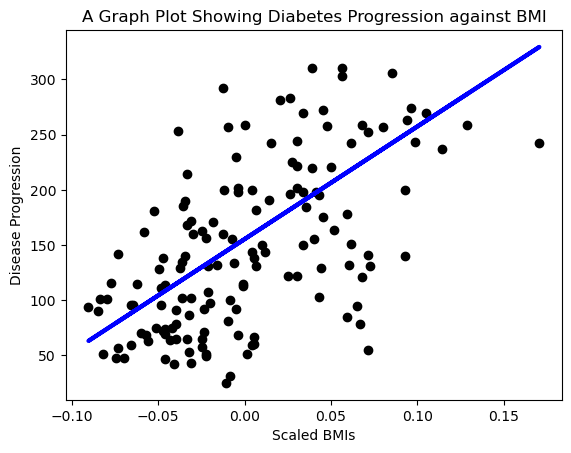

In [6]:
# Create a scatter plot
plt.scatter(X_test, y_test, color = 'black')

# Plot the predictions
plt.plot(X_test, y_pred, color = 'blue', linewidth = 3)

#Add labels and a title
plt.xlabel('Scaled BMIs')
plt.ylabel('Disease Progression')
plt.title('A Graph Plot Showing Diabetes Progression against BMI')

# Draw the plot
plt.show()



In [7]:
# Import KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import pandas as pd

X_new = np.array([
    [10, 2],
    [50, 5]
])

churn_df = pd.read_csv("Data/telecom_churn.csv")
y = churn_df["Churn"].values
X = churn_df[["tenure", "MonthlyCharges"]].values

# Create a KNN classifier with 6 neighbors
knn = KNeighborsClassifier(n_neighbors=6)

# Fit the classifier to the data
knn.fit(X, y)
#Now that your KNN classifier has been fit to the data,
#it can be used to predict the labels of new data points.

# Predict the labels for the X_new
y_pred = knn.predict(X_new)

# Print the predictions
print("Predictions: {}".format(y_pred))

#The model has predicted the first and third customers
#will not churn in the new array


Predictions: ['No' 'No']


In [8]:
from sklearn.model_selection import train_test_split

X = churn_df.select_dtypes(include="number").values
y = (churn_df["Churn"] == "Yes").astype(int).values

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
knn = KNeighborsClassifier(n_neighbors=5)

# Fit the classifier to the training data
knn.fit(X_train, y_train)
# Print the accuracy
print(knn.score(X_test, y_test))

#split the dataset, fit a KNN model, and found its accuracy to be 77%


0.772888573456352


In [9]:
# Create neighbors
neighbors = np.arange(1, 13)
train_accuracies = {}
test_accuracies = {}

for neighbor in neighbors:
  
	# Set up a KNN Classifier
	knn = KNeighborsClassifier(n_neighbors=neighbor)
  
	# Fit the model
	knn.fit(X_train, y_train)
  
	# Compute accuracy
	train_accuracies[neighbor] = knn.score(X_train, y_train)
	test_accuracies[neighbor] = knn.score(X_test, y_test)
print(neighbors, '\n', train_accuracies, '\n', test_accuracies)

#The training accuracy decreases as the number of neighbors initially gets larger, and vice versa for the testing accuracy

[ 1  2  3  4  5  6  7  8  9 10 11 12] 
 {1: 0.981008164714235, 2: 0.8610223642172524, 3: 0.8633297834575789, 4: 0.836528221512247, 5: 0.8363507277245297, 6: 0.820021299254526, 7: 0.8209087681931132, 8: 0.8161164359247426, 9: 0.8154064607738729, 10: 0.8116790912318069, 11: 0.8115015974440895, 12: 0.8116790912318069} 
 {1: 0.7182398864442867, 2: 0.7615330021291696, 3: 0.752306600425834, 4: 0.7622427253371186, 5: 0.772888573456352, 6: 0.7792760823278921, 7: 0.7785663591199432, 8: 0.7842441447835344, 9: 0.7757274662881476, 10: 0.7771469127040455, 11: 0.7750177430801988, 12: 0.7792760823278921}


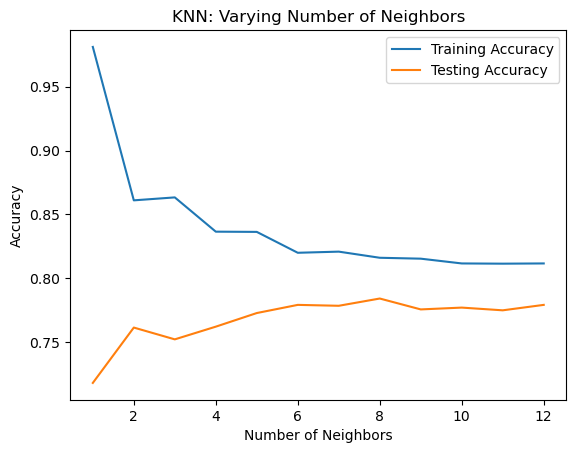

In [10]:
# Add a title
plt.title("KNN: Varying Number of Neighbors")

# Plot training accuracies
plt.plot(neighbors, train_accuracies.values(), label="Training Accuracy")

# Plot test accuracies
plt.plot(neighbors, test_accuracies.values(), label="Testing Accuracy")

plt.legend()
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")

# Display the plot
plt.show()